<a href="https://colab.research.google.com/github/jean-mappelli/TECH_CHALLENGE_FASE_2_9IADT/blob/main/TECH_CHALLENGE_FASE_1_9IADT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importação das bibliotecas principais**
- pandas para manipulação e analise dos arquivos com dados tabulares
- numpy para manipulação de grandes volumes de dados
- matplotlib e seaborn para criação e apresentação de graficos que auxiliam na analise dos dados

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Realiuzar a importação do dataset** e analisar visualmente as colunas  disponiveis no dataset.

In [40]:
df = pd.read_csv("data_cancer_mama.csv")
display(df.head())
df.info()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

**Analise exploratoria de dados**

Avaliando as informações a cima, existem visivelmente duas colunas que não fornecem informações para prever o cancer de mama **id** e **Unnamed:32**.
Devem ser removidas para facilitar

In [41]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

A coluna **diagnosis** é claramente a nossa variavel target.


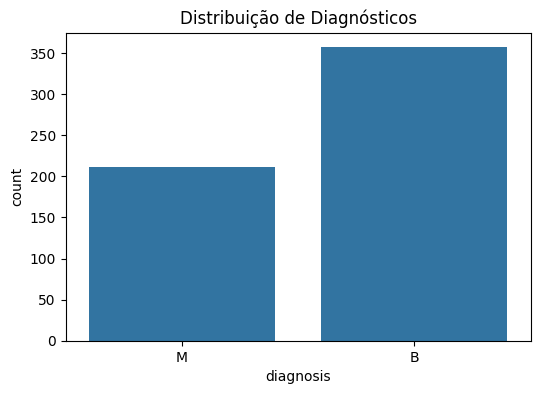

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diagnosis')
plt.title('Distribuição de Diagnósticos')
plt.show()


Os possiveis resultados são o tipo de cancer:

**'M'**: maligno

**'B'**: benigno

A base encontra-se levemente desbalanceada, podendo ser um desafio para a criação do modelo

Avaliando a **matriz de correlação** para identificar quais variavis estão mais ligadas entre sí

Vamos avaliar os valores médios (mean), pior valor (worst) e o erro padrão (se - standard error)

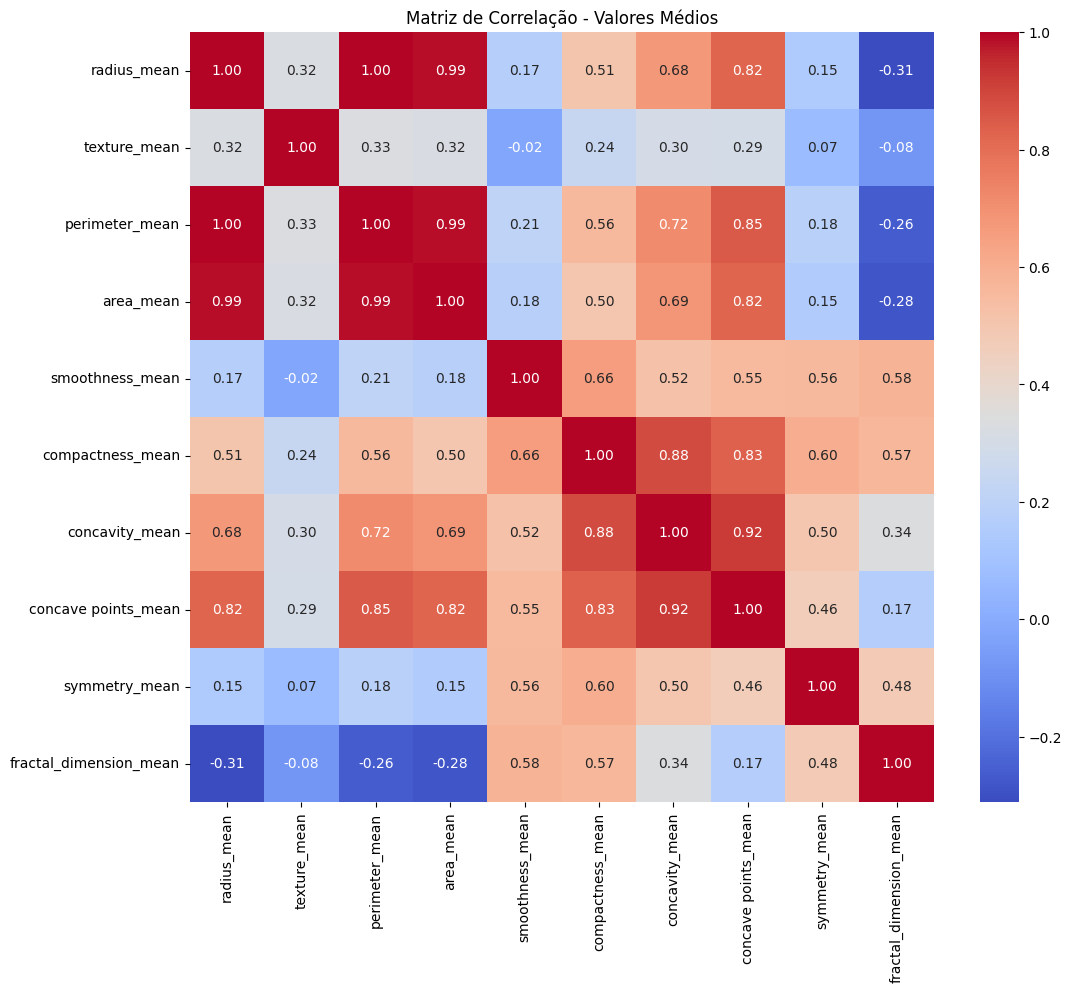

In [43]:
plt.figure(figsize=(12, 10))
colunas_mean = [col for col in df.columns if 'mean' in col]
sns.heatmap(df[colunas_mean].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Valores Médios')
plt.show()

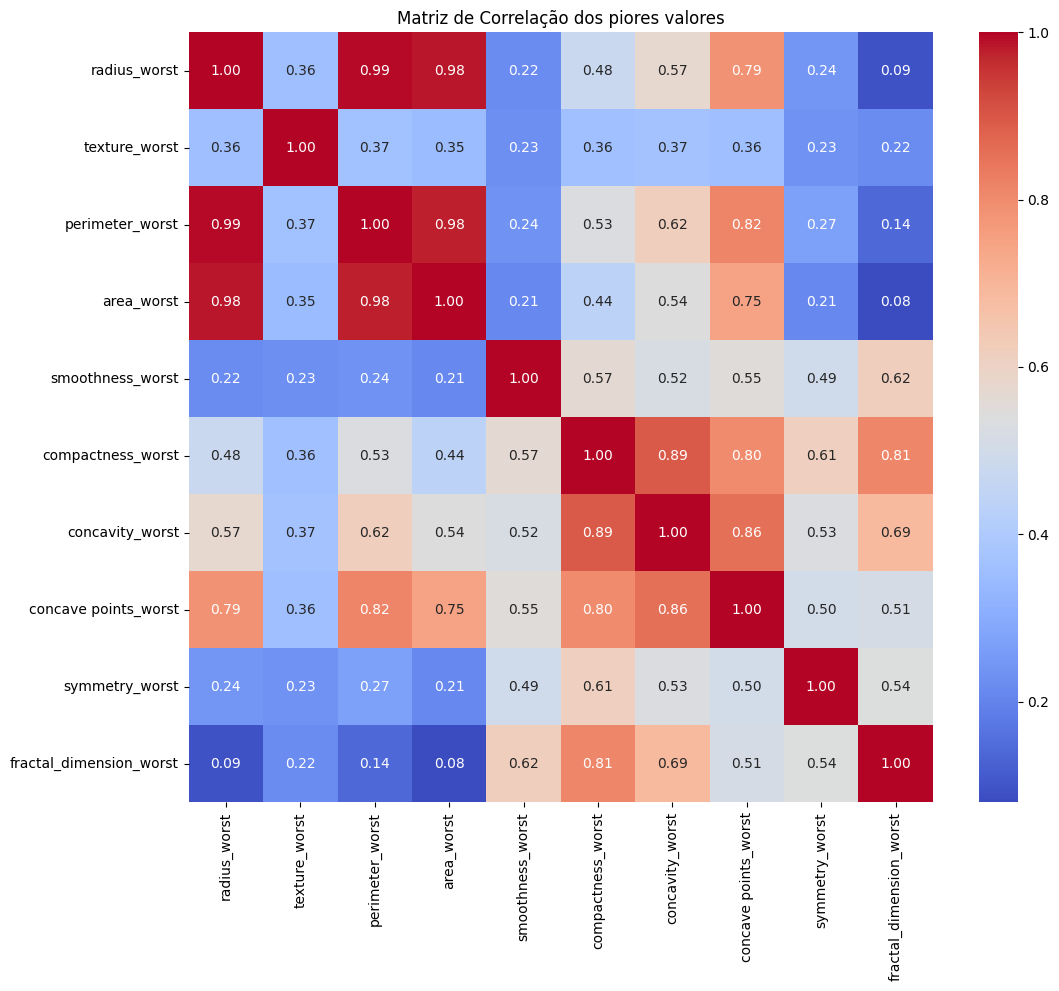

In [44]:
plt.figure(figsize=(12, 10))
colunas_mean = [col for col in df.columns if 'worst' in col]
sns.heatmap(df[colunas_mean].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos piores valores')
plt.show()

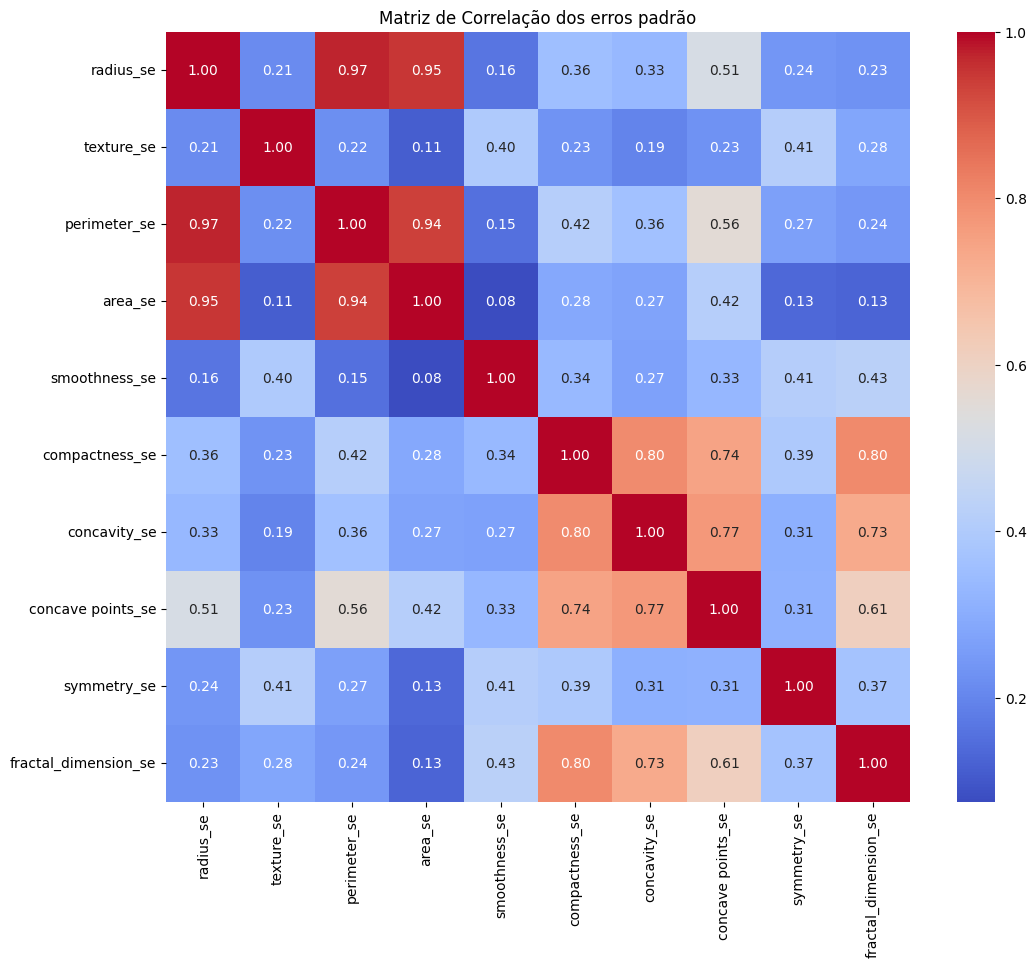

In [45]:
plt.figure(figsize=(12, 10))
colunas_mean = [col for col in df.columns if 'se' in col]
sns.heatmap(df[colunas_mean].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos erros padrão')
plt.show()

**Pré-processamento dos dados**

Transformar as classes M e B em numeros (0 e 1) com a tecnica do Label Encoding.

E separar as variáveis do  alvo.


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [47]:
#Usando LabelEncoder para transformar variáveis categóricas em numéricas
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

#Separar as Variáveis (X) do Alvo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [48]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Divisão entre treino e teste**

80% da base para treino e 20% para teste costuma ser uma boa divisão para o modelo performar bem

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Padronização dos dados**

  Usando Standard Scaler pois modelos baseados em distancias são sensiveis a variáveis com grandezas muito diferentes.

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Treinamento do modelo**

Vamos treinar dois modelos com de classificação

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#modelos
modelo_lr = LogisticRegression(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

#Treinamento
modelo_lr.fit(X_train_scaled, y_train)
modelo_rf.fit(X_train_scaled, y_train)

#Predições
y_predito_lr = modelo_lr.predict(X_test_scaled)
y_predito_rf = modelo_rf.predict(X_test_scaled)

**Avaliação dos resultados**

A partir daqui podemos avaliar qual a melhor metrica para a validação e qual o modelo mais acertivo.

Usamos o classification report para nos auxiliar.

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("REGRESSÃO LOGÍSTICA")
print(classification_report(y_test, y_predito_lr, target_names=['Benigno (0)', 'Maligno (1)']))
print("\n")
print("RANDOM FOREST")
print(classification_report(y_test, y_predito_rf, target_names=['Benigno (0)', 'Maligno (1)']))



REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.99      0.97        72
 Maligno (1)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



RANDOM FOREST
              precision    recall  f1-score   support

 Benigno (0)       0.96      1.00      0.98        72
 Maligno (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



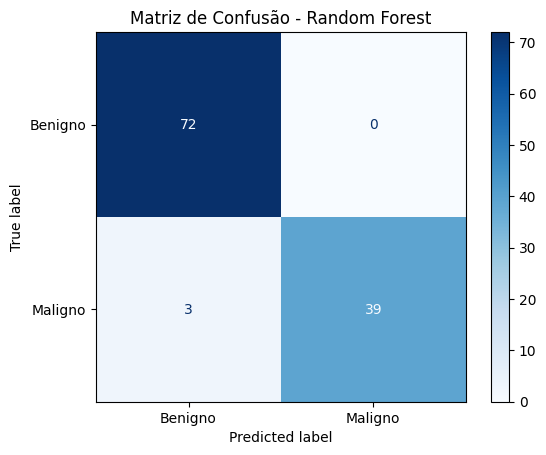

In [53]:
cm = confusion_matrix(y_test, y_predito_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

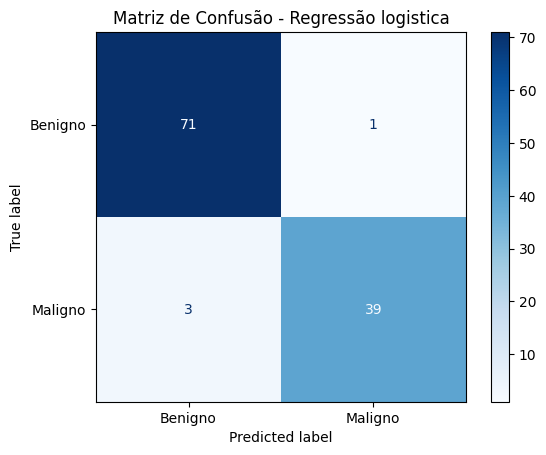

In [54]:
cm = confusion_matrix(y_test, y_predito_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Regressão logistica')
plt.show()

**Conclusões com base na avaliação do modelo**

Analisando os resultados dos modelos de Regressão Logística e Random Forest, observamos uma acurácia muito boa: 0.96 e 0.97, respectivamente. No entanto, no contexto de saude e areas correlatas, a acuracia isolada pode ser uma metrica enganosa.

Para este problema, a principal metrica é o Recall (sensibilidade) da classe maligna, pois o custo de um Falso Negativo (dizer que é benigno quando é um câncer maligno) é fatal, pois pode atrasar o tratamento da paciente.

Portanto, o objetivo é localizar o maximo valor de Recall da classe Maligna. Em ambos os modelos, obtivemos um Recall de 0.93 para tumores malignos. O F1-Score (que equilibra a precisão e o recall) ficou em fortíssimos 0.95 e 0.96 para a classe maligna, demonstrando que os modelos são robustos e não estão apenas chutando a classe majoritária.

Portanto, o modelo mais adequado para a utilização no auxilo médico seria a **regrssão logistica.**


**Importante**

Por se tratar de uma aplicação médica, o médico **sempre** deve ter a **decisão final no diagnostico:**.

############################################################################

## **TECH CHALLENGE FASE 2**

**Objetivo**
Otimizar o modelo da fase 1 do Tech challenge usando um algoritmo genético para extrair um melhor resultado do modelo a partir da alteração dos hiperparametros do modelo.

Os algoritmos genéticos podem ser representados de forma geral, com o seguinte diagrama:

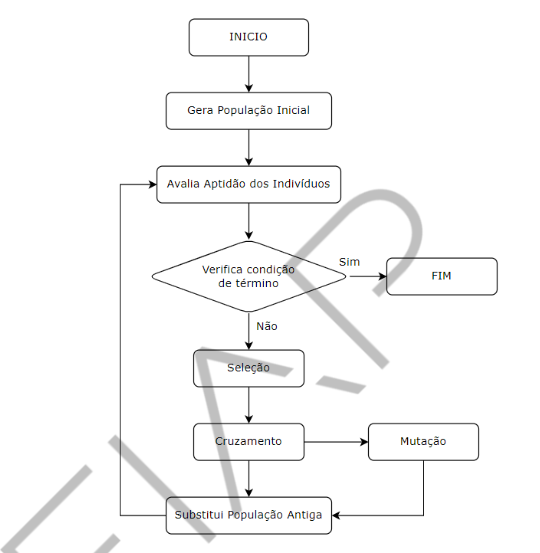

**Nessa seção será definida as importações e funções necessárias**

In [55]:
import random
import google.generativeai as genai
from sklearn.metrics import recall_score, f1_score, accuracy_score

Função auxiliar para acessar os hiperparametros do indivíduo
Os seguintes hiperparametros do modelo Randon Forest:
* n_estimators: Número total de árvores de decisão construídas pelo modelo.
* max_depth:Define a profundidade máxima (o número de níveis) permitida para cada árvore.
* min_samples_split:Quantidade mínima de dados (amostras) necessária para que um nó se divida em dois novos ramos.
* min_samples_leaf:Quantidade mínima de dados que deve existir em um nó folha.

In [56]:
#função auxiliar para resgatar os hiperparametros do individuo
def decodificar_genes(cromossomo):
    n_estimators = int(cromossomo[0])
    max_depth = None if cromossomo[1] == 0 else int(cromossomo[1])
    min_samples_split = int(cromossomo[2])
    min_samples_leaf = int(cromossomo[3])
    return n_estimators, max_depth, min_samples_split, min_samples_leaf

**Geração da população inicial**

Pode iniciar já com um dos indivíduos usado no treinamento do modelo da fase 1 do tech challenge (hiperparametros padrão do modelo);
Ou pode iniciar aleatoreamente

In [57]:
#Inicia a população com alguns individuos
def init_population(pop_size):
    pop = []
    # INSERÇÃO DO INDIVÍDUO INICIAL (SUPOSTA RESULTADO DA FASE 1)
    # [n_estimators=1, max_depth=None, min_samples_split=10, min_samples_leaf=1]
    pop.append([1, 0, 10, 1])

    # Preenchendo o resto da população aleatoriamente
    for _ in range(pop_size - 1):
        pop.append([
            random.randint(10, 300),  # n_estimators
            random.choice([0, 5, 10, 20, 30]), # max_depth (0 = None)
            random.randint(2, 10),    # min_samples_split
            random.randint(1, 10)     # min_samples_leaf
        ])
    return pop


Avalia cada indivíduo treinando o modelo e atribuindo uma nota baseada no seu desempenho com os dados de teste.

A nota final é composta por 70% do valor de Recall e 30% do F1-score, que atua como um critério de desempate.

In [58]:
#função de fitnes para permitir comparar com outro individuo
def fitness(cromossomo):
    n_est, max_d, min_split, min_leaf = decodificar_genes(cromossomo)
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    # Prioridade para o Recall (70%) e F1 (30%)
    return (recall_score(y_test, y_pred) * 0.7) + (f1_score(y_test, y_pred) * 0.3)


A seleção por torneio sorteia aleatoriamente dois indivíduos da população para competirem entre si.
O indivíduo que possuir a melhor nota na função de fitness vence e é selecionado para passar seus genes adiante.


In [59]:
# Seleção por Torneio
def selection(population, fitnesses):
    selected = []
    for _ in range(len(population)):
        i, j = random.sample(range(len(population)), 2)
        selected.append(population[i] if fitnesses[i] > fitnesses[j] else population[j])
    return selected


A função de cruzamento combinando os hiperparâmetros de dois individuos para gerar dois novos indivíduos. Ela divide a lista de parâmetros dos pais pela metade e as mistura, gerando dois "filhos" que herdam um conjunto de características de ambos.

**Exemplo Single-Point:**

Pai A: [100, 10, 2, 1]

Pai B: [300, 30, 5, 4]

O Processo:

Cortamos o Pai A na metade: [100, 10] | [2, 1]

Cortamos o Pai B na metade: [300, 30] | [5, 4]

Resultado:

Filho 1 (Metade 1 do Pai A + Metade 2 do Pai B): [100, 10, 5, 4]

Filho 2 (Metade 1 do Pai B + Metade 2 do Pai A): [300, 30, 2, 1]

In [60]:
# Cruzamento de dois pontos
def crossover(parent1, parent2):
    meio = len(parent1) // 2
    child1 = parent1[:meio] + parent2[meio:]
    child2 = parent2[:meio] + parent1[meio:]
    return child1, child2


A mutação altera um gene aleatório do cromossomo com base em uma taxa de probabilidade (mutation_rate).

Isso previne a estagnação do modelo em soluções locais, garantindo a exploração de novos hiperparâmetros.

In [61]:
# Mutação das especies
def mutation(cromossomo, mutation_rate):
    if random.random() < mutation_rate:
        cromossomo[0] = random.randint(10, 300)
    if random.random() < mutation_rate:
        cromossomo[1] = random.choice([0, 5, 10, 20, 30])
    if random.random() < mutation_rate:
        cromossomo[2] = random.randint(2, 10)
    if random.random() < mutation_rate:
        cromossomo[3] = random.randint(1, 10)
    return cromossomo

Função principal do algoritmo genetico, fazendo as interações necessárias nos individuos.


In [62]:
#Algoritmo genetico
def run_genetic_algorithm(pop_size=20, generations=10, mutation_rate=0.1):
    population = init_population(pop_size) #População inical, pode usar ou não o individuo (hiperparametros) da fase 1 do tech chalenge.
    best_chromosome = None
    best_fitness = -1

    print("\nIniciando Evolução...")
    for gen in range(generations):
        fitnesses = [fitness(ind) for ind in population]

        #Regista o melhor individuo para o elitismo
        for ind, fit in zip(population, fitnesses):
            if fit > best_fitness:
                best_fitness = fit
                best_chromosome = ind.copy()

        selected = selection(population, fitnesses)
        next_gen = []
        next_gen.append(best_chromosome) #Elitismo, mantém o melhor indivíduo

        # realiza a seleção da proxima geração
        for i in range(1, len(selected), 2):
            if i+1 < len(selected):
                p1, p2 = selected[i], selected[i+1]
                c1, c2 = crossover(p1, p2)
                next_gen.extend([mutation(c1, mutation_rate), mutation(c2, mutation_rate)])

        # Ajusta tamanho da população caso seja ímpar
        population = next_gen[:pop_size]
        print(f"Geração {gen+1} | Melhor Fitness: {best_fitness:.4f}")

    return best_chromosome, best_fitness


Aqui é de fato a execução do algoritmo genético, utilizando o modelo Random Forest até alcançar um bom resultado.

In [64]:
#Estanciando o modelo Padrão da Biblioteca
modelo_rf = RandomForestClassifier(n_estimators=1, max_depth=None, min_samples_split=10, min_samples_leaf=1,random_state=42)
modelo_rf.fit(X_train_scaled, y_train) #fit do dataset
y_pred_base = modelo_rf.predict(X_test_scaled) #predição
baseline_recall = recall_score(y_test, y_pred_base)
print(f"Recall Original (Random Forest): {baseline_recall:.4f}")


#executa o algoritmo genético e seleciona o melhor 'cromossomo' (individuo)
melhor_cromossomo, melhor_fit = run_genetic_algorithm(pop_size=10, generations=8, mutation_rate=0.20)
#Interpreta os hiperparametros do melhor individuo
n_est_opt, max_d_opt, min_split_opt, min_leaf_opt = decodificar_genes(melhor_cromossomo)

print("\n--- COMPARAÇÃO DE DESEMPENHO ---")
print(f"Hiperparâmetros Otimizados: n_estimators={n_est_opt}, max_depth={max_d_opt}, min_samples_split={min_split_opt}, min_samples_leaf={min_leaf_opt}")

# Avaliação Final
modelo_rf_otimizado = RandomForestClassifier(
    n_estimators=n_est_opt,
    max_depth=max_d_opt,
    min_samples_split=min_split_opt,
    min_samples_leaf=min_leaf_opt,
    random_state=42
)
modelo_rf_otimizado.fit(X_train_scaled, y_train)
y_pred_opt = modelo_rf_otimizado.predict(X_test_scaled)

print(f"Recall Original (Default) : {baseline_recall:.4f}")
print(f"Recall Otimizado (GA)     : {recall_score(y_test, y_pred_opt):.4f}")
print(f"Acurácia Otimizada        : {accuracy_score(y_test, y_pred_opt):.4f}")




Recall Original (Random Forest): 0.8095

Iniciando Evolução...
Geração 1 | Melhor Fitness: 0.9389
Geração 2 | Melhor Fitness: 0.9389
Geração 3 | Melhor Fitness: 0.9389
Geração 4 | Melhor Fitness: 0.9389
Geração 5 | Melhor Fitness: 0.9389
Geração 6 | Melhor Fitness: 0.9389
Geração 7 | Melhor Fitness: 0.9389
Geração 8 | Melhor Fitness: 0.9389

--- COMPARAÇÃO DE DESEMPENHO ---
Hiperparâmetros Otimizados: n_estimators=148, max_depth=30, min_samples_split=6, min_samples_leaf=1
Recall Original (Default) : 0.8095
Recall Otimizado (GA)     : 0.9286
Acurácia Otimizada        : 0.9737


Integração com LLM comercial para exercitar a utilização da ferramenta

In [65]:
#Integração com uma LLM
genai.configure(api_key="************")

def gerar_relatorio_medico(dados_originais, diagnostico_modelo, confianca):
    # Formata os dados reais do tumor (sem escala) para leitura médica
    dados_formatados = "\n".join([f"- {col}: {val:.4f}" for col, val in dados_originais.items()])

    prompt = f"""
    Atue como um médico oncologista sênior.
    Analise o resultado do nosso modelo de IA para detecção de câncer de mama.
    DADOS BIOMÉTRICOS REAIS DO TUMOR (Extraídos da paciente):
    {dados_formatados}
    DIAGNÓSTICO DA IA: {diagnostico_modelo}
    NÍVEL DE CONFIANÇA DO MODELO: {confianca:.2f}%
    Escreva um breve laudo médico clínico:
    """

    try:
        model = genai.GenerativeModel('gemini-3-flash-preview')
        return model.generate_content(prompt).text
    except Exception as e:
        return f"Erro na geração via LLM: {e}"

# Selecionando um caso do Teste
idx_amostra = 0

# A predição deve utilizar os dados matematicamente escalonados
dados_escalonados_predicao = X_test_scaled[idx_amostra].reshape(1, -1)
probabilidades = modelo_rf_otimizado.predict_proba(dados_escalonados_predicao)[0]
predicao = modelo_rf_otimizado.predict(dados_escalonados_predicao)[0]

diagnostico = "Maligno" if predicao == 1 else "Benigno"
confianca = probabilidades[1] * 100 if predicao == 1 else probabilidades[0] * 100

# A IA Generativa recebe os dados REAIS, sem a transformação do StandardScaler
dados_originais_paciente = X_test.iloc[idx_amostra].to_dict()

print("\n" + "="*60)
print("LAUDO CLÍNICO GERADO POR IA (BASEADO NOS DADOS ORIGINAIS)")
print("="*60)
print(gerar_relatorio_medico(dados_originais_paciente, diagnostico, confianca))


LAUDO CLÍNICO GERADO POR IA (BASEADO NOS DADOS ORIGINAIS)
Este é um laudo médico simulado, elaborado sob a perspectiva de um oncologista sênior, integrando os dados biométricos apresentados e a análise do modelo de inteligência artificial.

---

### **LAUDO DE AVALIAÇÃO ONCOLÓGICA E SUPORTE À DECISÃO CLÍNICA**

**DATA:** 23 de Maio de 2024
**PACIENTE:** [Omitido/Identificação Referencial]
**SOLICITANTE:** Equipe de Triagem Digital / Oncologia

#### **1. ANÁLISE DOS DADOS BIOMÉTRICOS (MORFOMETRIA NUCLEAR)**
Os parâmetros biométricos extraídos da amostra (presumivelmente via PAAF - Punção Aspirativa por Agulha Fina) apresentam indicadores de estabilidade celular. Observo que:
*   **Dimensões:** O raio médio (11.41) e a área média (403.30) estão situados em faixas comumente associadas a tecidos normais ou alterações benignas.
*   **Morfologia:** Os valores de concavidade (0.0351) e pontos côncavos médios (0.0262) são baixos, sugerindo núcleos celulares com contornos regulares e ausência 